In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math
plt.rcParams["figure.figsize"] = (24,18)

from cv_utils import *
from houghlines_process import *
from dexined import DexiNed 

import torch
import torchvision.transforms as transforms

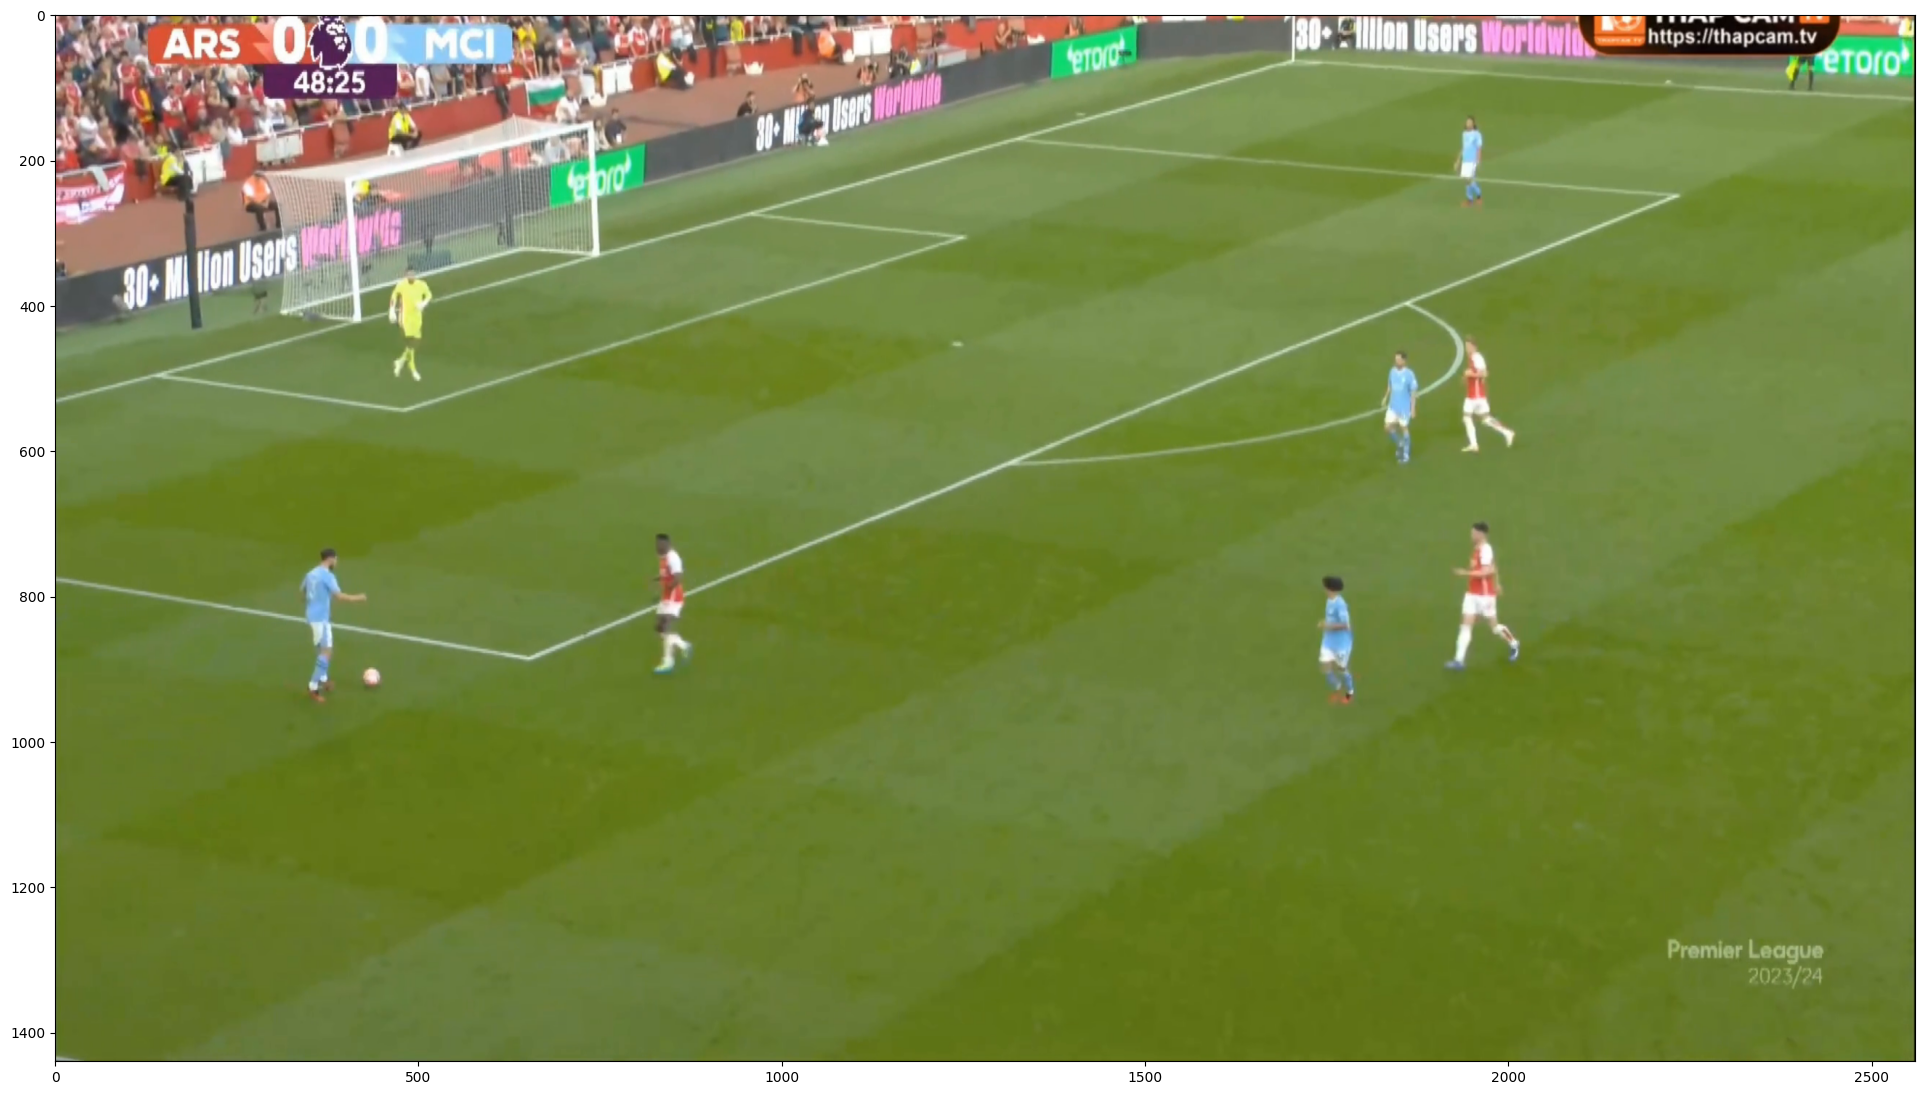

In [2]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name = 'real_test'
images_path = os.path.join(data_path, 'images' + '/' + vid_name)

image_path = os.path.join(images_path, '000000000070.png')#sorted(os.listdir(images_path))[8])
rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

cropped_image = pitch_segment(rgb_image, visualize=False)
orig_h, orig_w, _ = cropped_image.shape

plt.figure()
plt.imshow(cropped_image[:, :, ::-1])


0: 576x1024 8 persons, 1 ball, 5.2ms
Speed: 3.9ms preprocess, 5.2ms inference, 0.8ms postprocess per image at shape (1, 3, 576, 1024)


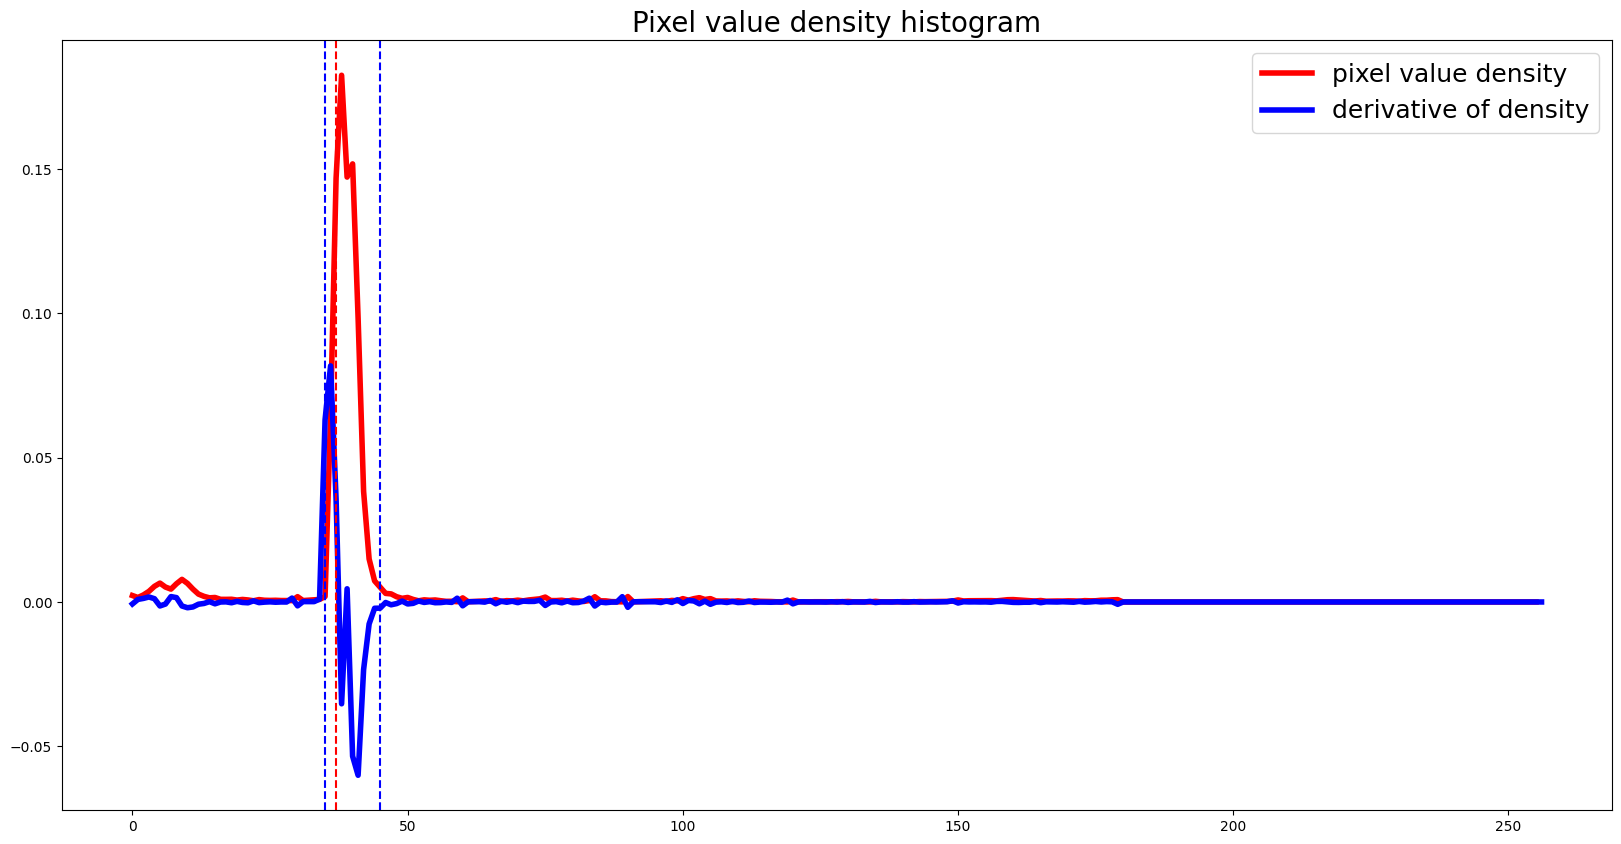

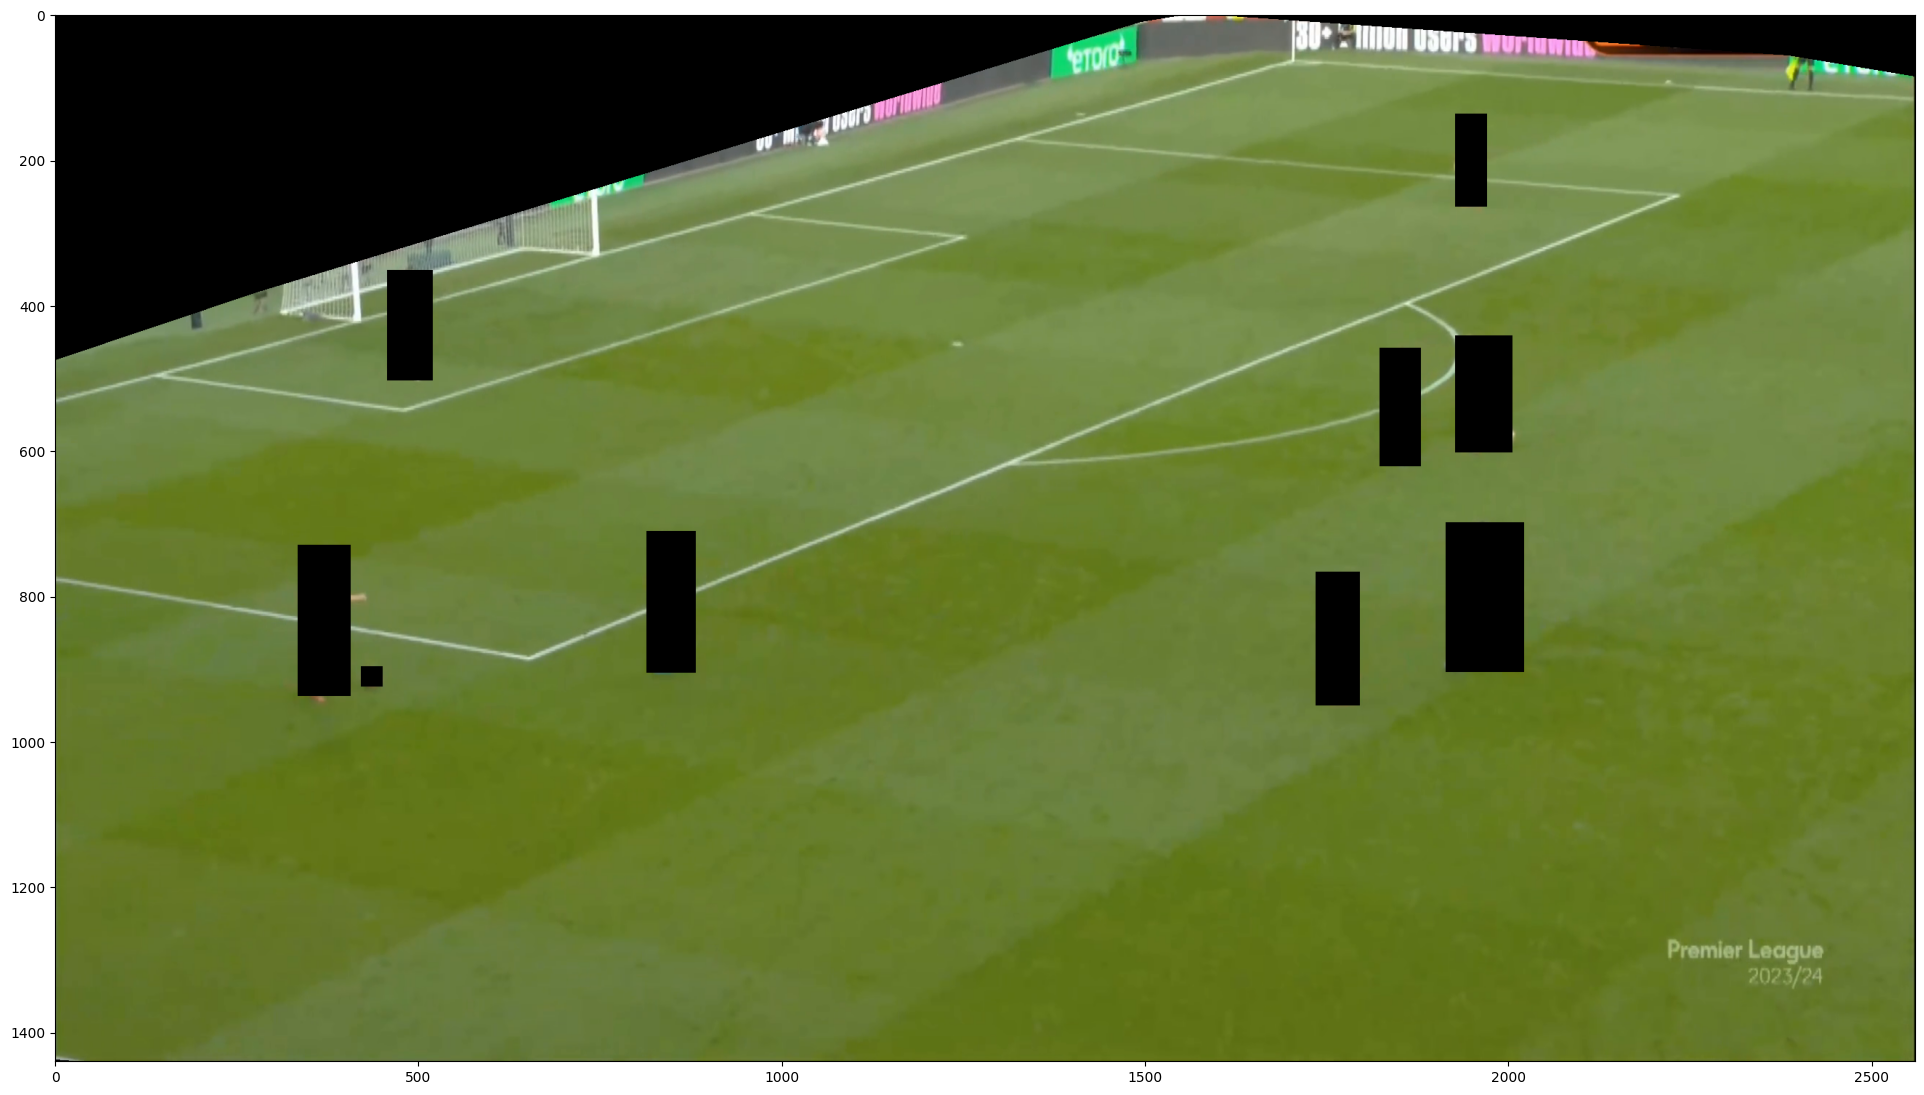

In [3]:
hsv_image = cv2.cvtColor(cv2.medianBlur(cv2.GaussianBlur(cropped_image,
                                                         (5,5),0), 5), cv2.COLOR_BGR2HSV)
hue = hsv_image[:, :, 0]
start_index, stop_index = find_peak_range(hue, visualize=True)
lower_green = start_index
upper_green = stop_index

mask_green = cv2.inRange(hue, lower_green, upper_green)

_, rect, hull = detect_largest_contour(mask_green)

mask = np.zeros_like(cropped_image)
cv2.fillPoly(mask, [hull], (255, 255, 255))

pitch_cropped_image = cv2.bitwise_and(cropped_image, mask)

filtered_player_image = pitch_cropped_image.copy()

model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model = YOLO(os.path.join(model_path, "yolov8n_2nd_train.pt"))

# Remove players from the image using YOLO predictions:
results = model.predict(pitch_cropped_image)
for result in results:
    boxes = result.boxes
    classes = result.names
    for box in boxes:
        coord = box.xyxy.cpu().detach().int().tolist()[0]
        (startX, startY, endX, endY) = coord

        # Draw black rectangle on the mask using bounding box coordinates
        cv2.rectangle(filtered_player_image, [startX, startY], [endX, endY], (0, 0, 0), -1)

plt.figure()
plt.imshow(filtered_player_image[:, :, ::-1])

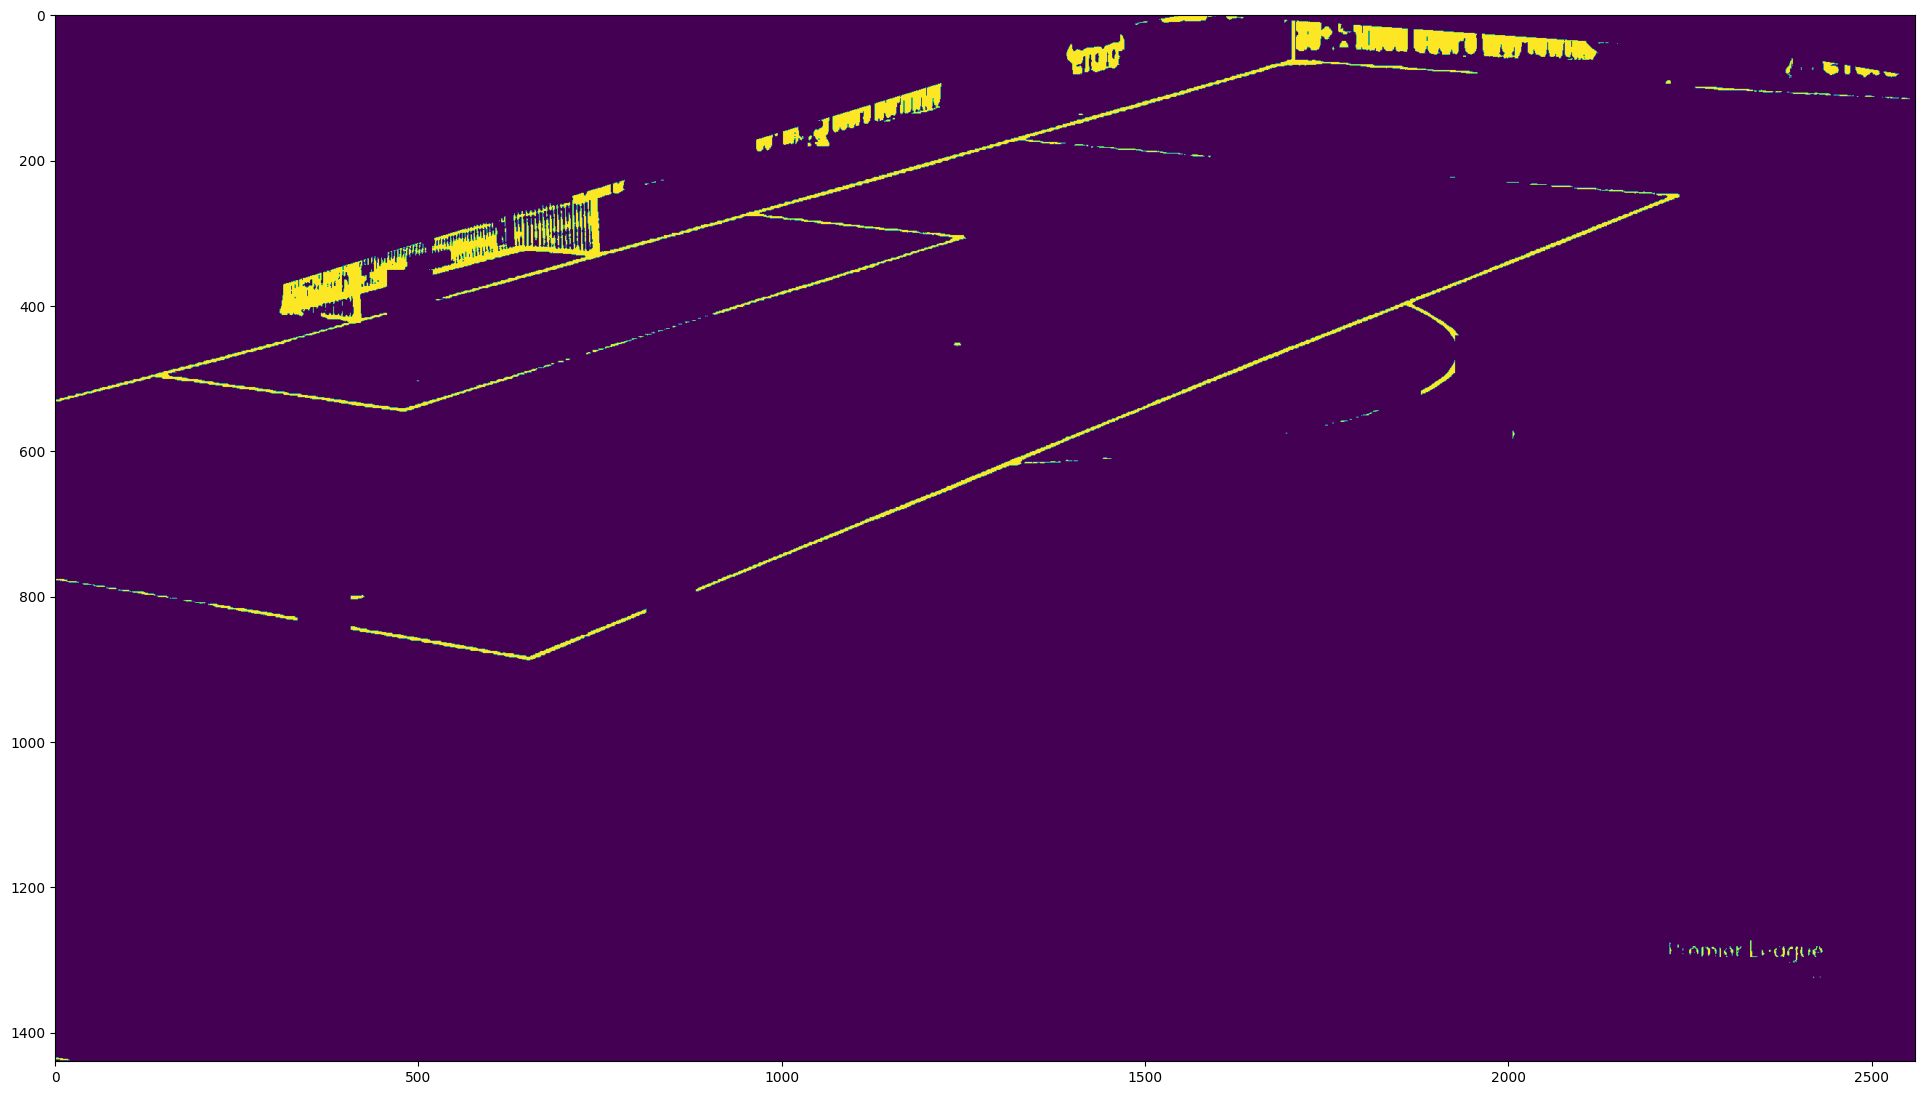

In [4]:
temp = cropped_image.copy()

hls_image = cv2.cvtColor(filtered_player_image, cv2.COLOR_RGB2HLS)
lightness = hls_image[:,:, 1]

start_index, stop_index = find_peak_range(lightness, visualize=False)

lower_light = 150
higher_light = 255

mask_light = cv2.inRange(lightness, lower_light, higher_light)
plt.figure()
plt.imshow(mask_light)

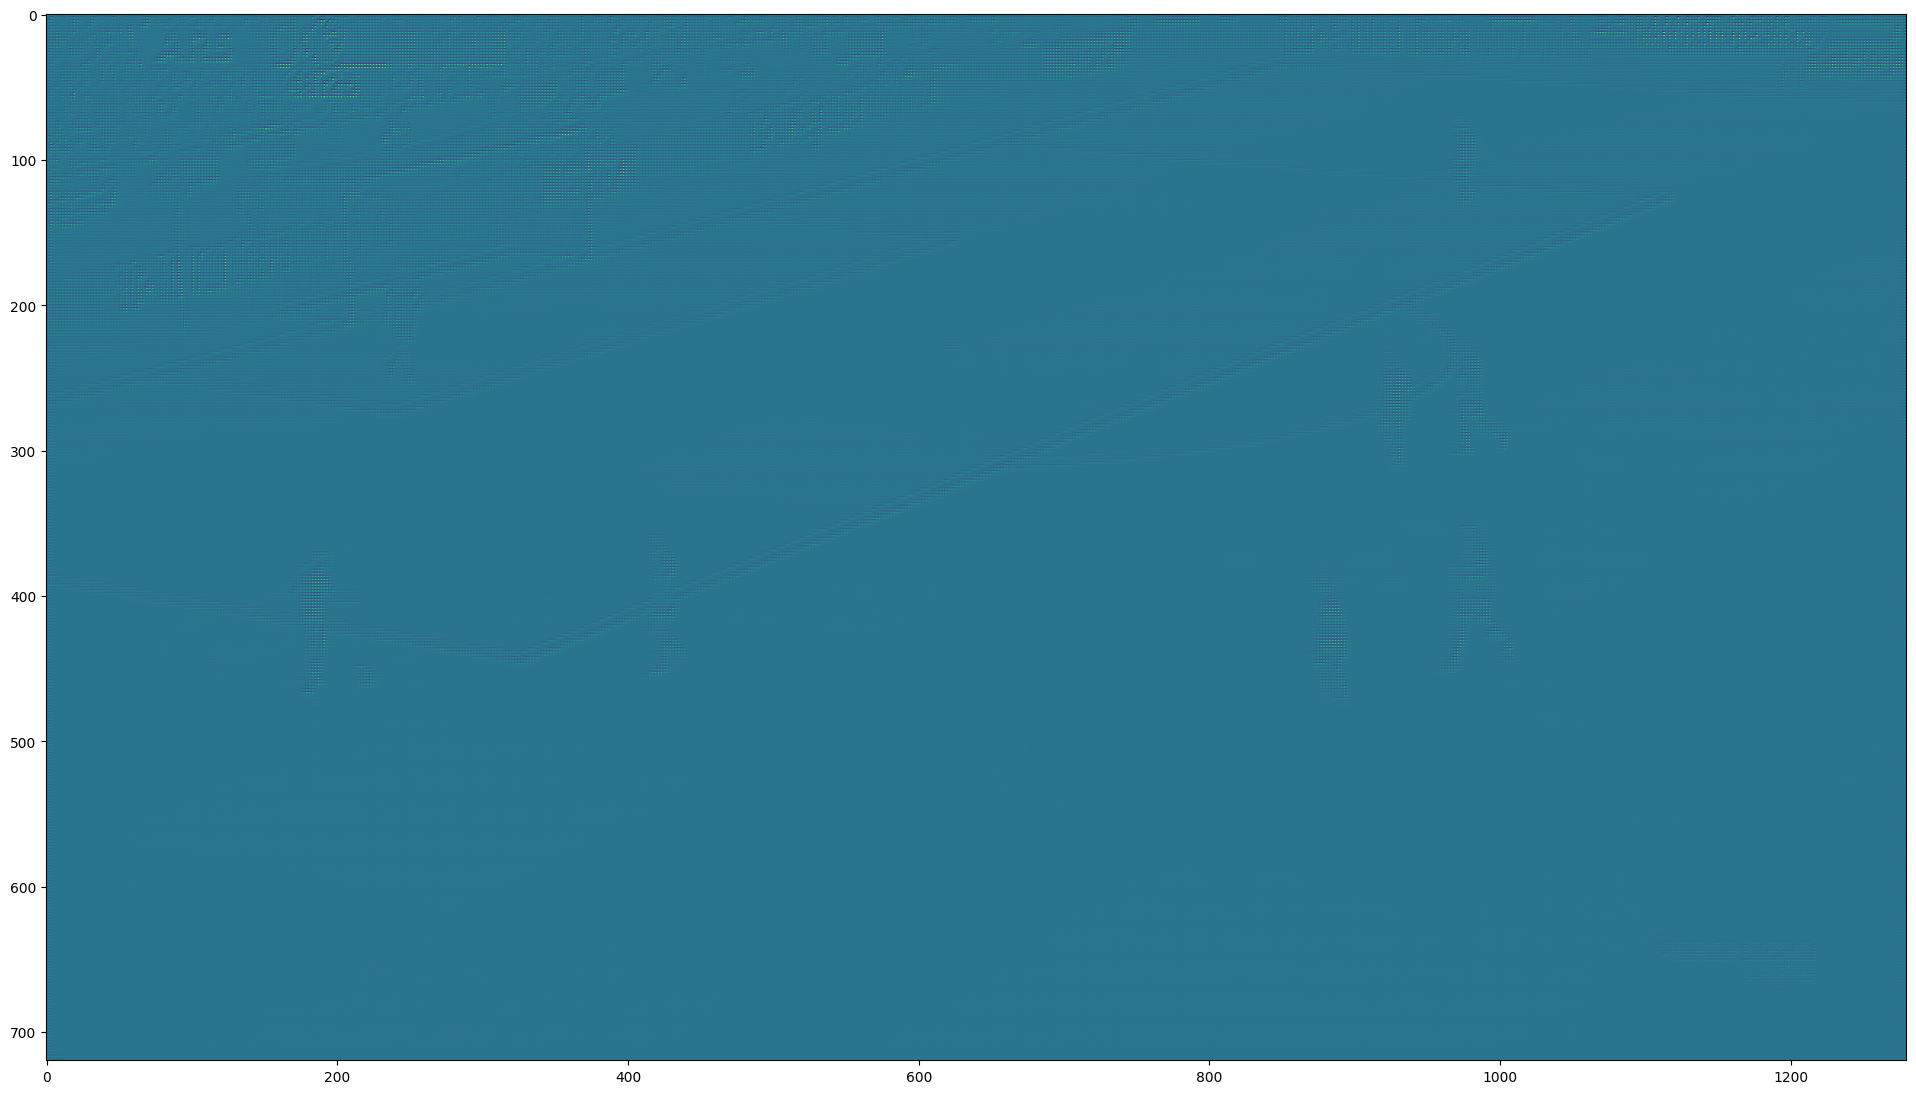

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = DexiNed().to(device)

transform = transforms.ToTensor()
input_image = cv2.resize(cropped_image, (1280, 720))
input = torch.unsqueeze(transform(input_image), 0).to(device)

output = model(input)[0].detach().cpu().squeeze().numpy()
plt.imshow(output)
